In [2]:
### CLEANING NATIONAL PARK AND MERGING ECONOMIC DATA 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
DF_visit = pd.read_csv('nationalparks.csv')
DF_econ = pd.read_csv("economics.csv")

In [28]:
DF_visit.head()
DF_econ.head()

,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput
0,2024,ACAD,Acadia National Park,"3,961,661","$538,906","5,304","$243,133","$459,921","$744,545"
1,2024,ARCH,Arches National Park,"1,466,528","$287,785","2,502","$94,522","$183,289","$312,122"
2,2024,BADL,Badlands National Park,"1,094,245","$143,206","1,410","$58,901","$111,301","$191,413"
3,2024,BIBE,Big Bend National Park,"561,458","$56,817",585,"$17,269","$34,443","$63,707"
4,2024,BISC,Biscayne National Park,"512,213","$39,679",362,"$19,190","$34,520","$55,023"


In [29]:
DF_visit['Month_Num'] = pd.to_datetime(DF_visit['Month'], format='%B').dt.month
DF_visit['Date'] = pd.to_datetime(DF_visit.Year.astype(str) + '/' + DF_visit.Month_Num.astype(str) + '/01')
DF_visit["Join Code"] = DF_visit["Park Code"] + DF_visit["Year"].astype(str)
DF_visit.head()


,Park Name,Park Code,State,Year,Month,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,Backcountry Campers,Misc Campers,Non-Recreation Overnight Stays,Total Overnight Stays,Month_Num,Date,Join Code
0,Crater Lake National Park,CRLA,OR,2015,January,10489,2100,39953,1050,0,0,0,0,162,0,0,162.0,1,2015-01-01,CRLA2015
1,Crater Lake National Park,CRLA,OR,2015,February,8635,2400,33682,1200,0,0,0,0,173,0,0,173.0,2,2015-02-01,CRLA2015
2,Crater Lake National Park,CRLA,OR,2015,March,13938,2800,54242,1400,0,0,0,0,273,0,0,273.0,3,2015-03-01,CRLA2015
3,Crater Lake National Park,CRLA,OR,2015,April,16918,4800,63625,2400,62,0,0,0,171,0,0,233.0,4,2015-04-01,CRLA2015
4,Crater Lake National Park,CRLA,OR,2015,May,48217,4900,274731,2450,3457,0,0,2309,224,0,0,5990.0,5,2015-05-01,CRLA2015


In [30]:
DF_visit_by_year = DF_visit.groupby(["Park Code","Year"]).agg({"Park Name": "first", "State": "first","Recreation Visitors":"sum", "Non-Recreation Visitors":"sum","Recreation Visitor Hours":"sum", "Non-Recreation Hours":"sum", "Concession Lodging":"sum", "Tent Campers":"sum", "RV Campers":"sum", "Concession Camping":"sum","Backcountry Campers":"sum","Misc Campers":"sum", "Non-Recreation Overnight Stays":"sum", "Total Overnight Stays":"sum", "Join Code":"first"})
DF_visit_by_year.head()

Park Name State  Recreation Visitors  \
Park Code Year                                                    
ACAD      2015  Acadia National Park   ME               2811184   
          2016  Acadia National Park   ME               3303393   
          2017  Acadia National Park   ME               3509271   
          2018  Acadia National Park   ME               3537575   
          2019  Acadia National Park   ME               3437286   

                Non-Recreation Visitors  Recreation Visitor Hours  \
Park Code Year                                                      
ACAD      2015                    47100                  14452151   
          2016                    47100                  22698596   
          2017                    47100                  24014370   
          2018                    47100                  23613754   
          2019                    47100                  23195664   

                Non-Recreation Hours  Concession Lodging  Tent Campers  \
Park Code Year                                                           
ACAD      2015                 47100                   0        135000   
          2016                 47100                   0        152811   
          2017                 47100                   0        152586   
          2018                 47100                   0        144744   
          2019                 47100                   0        140985   

                RV Campers  Concession Camping  Backcountry Campers  \
Park Code Year                                                        
ACAD      2015       32094                   0                 1233   
          2016       46629                 977                 1324   
          2017       55812                1657                 1597   
          2018       58215                1364                 1472   
          2019       57696                1090                 1284   

                Misc Campers  Non-Recreation Overnight Stays  \
Park Code Year                                                 
ACAD      2015          8343                               0   
          2016          8563                               0   
          2017         10889                               0   
          2018         11698                               0   
          2019         11674                               0   

                Total Overnight Stays Join Code  
Park Code Year                                   
ACAD      2015               176670.0  ACAD2015  
          2016               210304.0  ACAD2016  
          2017               222541.0  ACAD2017  
          2018               217493.0  ACAD2018  
          2019               212729.0  ACAD2019

In [31]:
DF_econ["Join Code"] = DF_econ["Code"] + DF_econ["Year"].astype(str)
DF_econ.head()

,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput,Join Code
0,2024,ACAD,Acadia National Park,"3,961,661","$538,906","5,304","$243,133","$459,921","$744,545",ACAD2024
1,2024,ARCH,Arches National Park,"1,466,528","$287,785","2,502","$94,522","$183,289","$312,122",ARCH2024
2,2024,BADL,Badlands National Park,"1,094,245","$143,206","1,410","$58,901","$111,301","$191,413",BADL2024
3,2024,BIBE,Big Bend National Park,"561,458","$56,817",585,"$17,269","$34,443","$63,707",BIBE2024
4,2024,BISC,Biscayne National Park,"512,213","$39,679",362,"$19,190","$34,520","$55,023",BISC2024


In [32]:
DF_all = pd.merge(DF_visit_by_year, DF_econ, on = "Join Code")
DF_all.head()

,Park Name,State,Recreation Visitors,Non-Recreation Visitors,Recreation Visitor Hours,Non-Recreation Hours,Concession Lodging,Tent Campers,RV Campers,Concession Camping,...,Join Code,Year,Code,Name,Recreation Visits,Visitor\nSpending,Jobs Supported,Labor Income,Value Added,Economic\nOutput
0,Acadia National Park,ME,2811184,47100,14452151,47100,0,135000,32094,0,...,ACAD2015,2015,ACAD,Acadia National Park,"2,811,184","$247,910.80","3,878","$102,112.70","$172,526.10","$304,623.50"
1,Acadia National Park,ME,3303393,47100,22698596,47100,0,152811,46629,977,...,ACAD2016,2016,ACAD,Acadia National Park,"3,303,394","$274,208.80","4,195","$111,087.10","$188,275.10","$332,786.30"
2,Acadia National Park,ME,3509271,47100,24014370,47100,0,152586,55812,1657,...,ACAD2017,2017,ACAD,Acadia National Park,"3,509,271","$284,459.80","4,163","$107,621.50","$185,248.30","$338,873.80"
3,Acadia National Park,ME,3537575,47100,23613754,47100,0,144744,58215,1364,...,ACAD2018,2018,ACAD,Acadia National Park,"3,537,575","$387,654","5,602","$171,668","$304,982","$521,454"
4,Acadia National Park,ME,3437286,47100,23195664,47100,0,140985,57696,1090,...,ACAD2019,2019,ACAD,Acadia National Park,"3,437,286","$379,517","5,474","$168,284","$298,961","$510,962"


In [33]:
DF_all.to_csv("Visit Econ Data.csv")


In [35]:
DF_all.columns = DF_all.columns.str.replace('\n', ' ').str.strip()

DF_all.to_csv("Visit Econ Data.csv", index=False)

In [12]:
### COLUMNS fixed (check below) 

In [36]:
print(DF_all.columns)

Index(['Park Name', 'State', 'Recreation Visitors', 'Non-Recreation Visitors',
       'Recreation Visitor Hours', 'Non-Recreation Hours',
       'Concession Lodging', 'Tent Campers', 'RV Campers',
       'Concession Camping', 'Backcountry Campers', 'Misc Campers',
       'Non-Recreation Overnight Stays', 'Total Overnight Stays', 'Join Code',
       'Year', 'Code', 'Name', 'Recreation Visits', 'Visitor Spending',
       'Jobs Supported', 'Labor Income', 'Value Added', 'Economic Output'],
      dtype='object')


In [14]:
### all code below is to make yearly colummns for the bar plot and merge them to be able to subtract 2019 visitors from 2020 

In [88]:

yearly = DF_all.groupby(["Park Name", "Year"])["Recreation Visitors"].sum().reset_index()


In [89]:
y2019 = yearly[yearly["Year"] == 2019]
y2020 = yearly[yearly["Year"] == 2020]


In [90]:
merged = pd.merge(y2019, y2020, on="Park Name", suffixes=("_2019", "_2020"))


In [91]:
merged["drop"] = merged["Recreation Visitors_2019"] - merged["Recreation Visitors_2020"]


In [92]:
top5 = merged.sort_values("drop", ascending=False).head(5)


In [93]:
sns.set_theme(palette='gist_earth')

In [94]:
sns.set_style("whitegrid")

In [20]:
### plot was created to show an overview of the top 10 most affected NP affected by COVID-19 by the number of recreational visitors lost . 
### also take into account different NP have different policies 
### we can possibily think about BIG BEND in Texas where there was probably little to no regulations 
#### whereas larger more commonly visited parks like Grand Canyon and Yosemite would have more strict regulations 

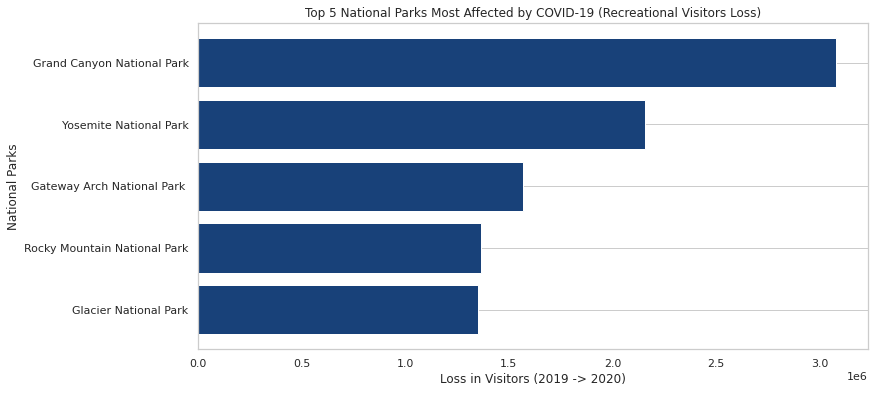

In [95]:
plt.figure(figsize=(12, 6))


plt.barh(top5["Park Name"], top5["drop"])

plt.xlabel("Loss in Visitors (2019 -> 2020)")
plt.ylabel("National Parks")
plt.title("Top 5 National Parks Most Affected by COVID-19 (Recreational Visitors Loss)")

plt.gca().invert_yaxis()  # biggest at top
plt.grid(axis="x")

plt.show()

In [22]:
#### side-by-side bar plots on NP visitations (2019 vs 2020 comparisons) 
### top 10 most affected not arranged but I could do that, I just don't think it really matters 

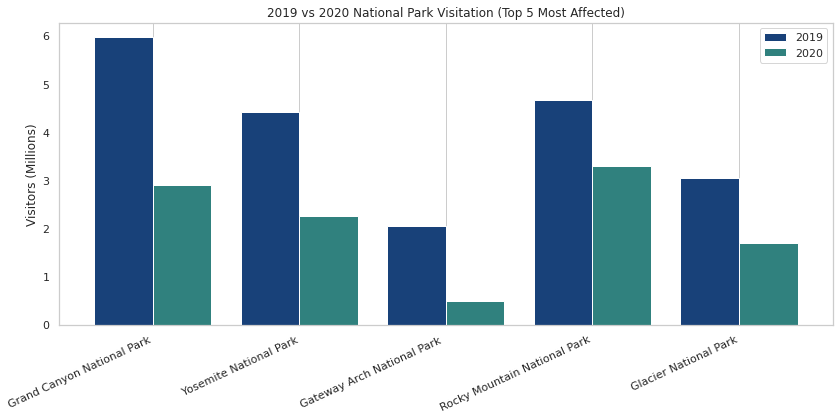

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to millions 
y2019 = top5["Recreation Visitors_2019"] / 1_000_000
y2020 = top5["Recreation Visitors_2020"] / 1_000_000

parks = top5["Park Name"]

x = np.arange(len(parks))
width = 0.4

plt.figure(figsize=(12, 6))

# Bars
plt.bar(x - width/2, y2019, width, label="2019")
plt.bar(x + width/2, y2020, width, label="2020")

# Labels and formatting 
plt.xticks(x, parks, rotation=25, ha="right")
plt.ylabel("Visitors (Millions)")
plt.title("2019 vs 2020 National Park Visitation (Top 5 Most Affected)")

plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [ ]:
### predictions for visitations for Grand Canyon and Economic Output 

In [25]:
## economic outcomes if 2020 didn't happen (is there a difference?) 

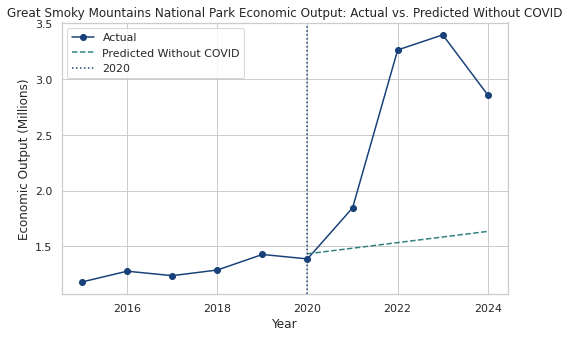

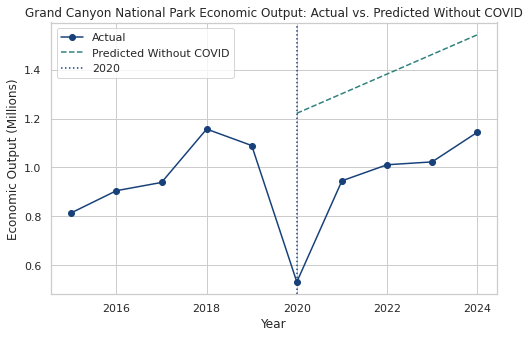

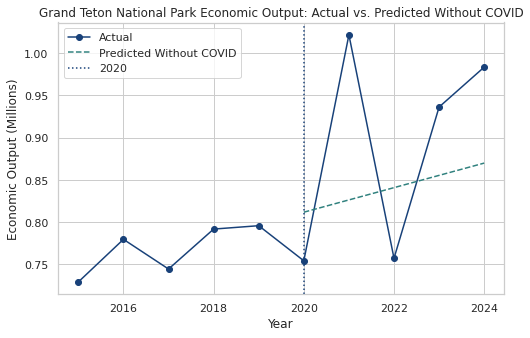

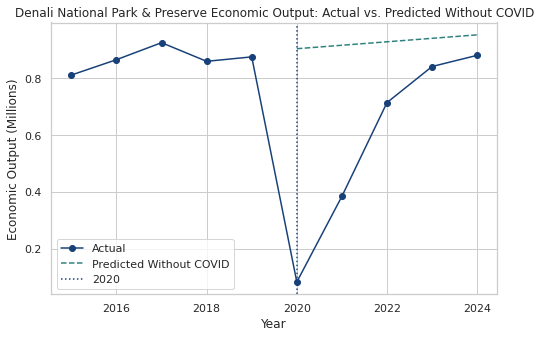

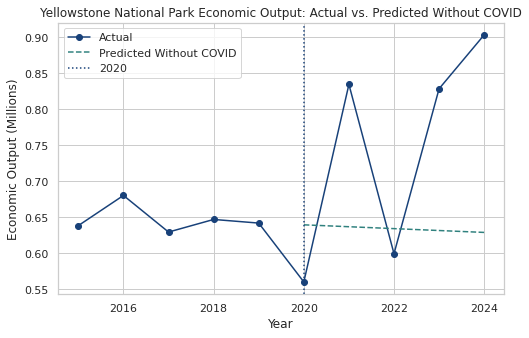

In [83]:
for park in top5:
    park_data = econ_yearly[econ_yearly["Park Name"] == park].sort_values("Year")

    pre_covid = park_data[park_data["Year"] < 2020]
    covid_forward = park_data[park_data["Year"] >= 2020]

    x = park_data["Year"]
    y = park_data["Economic Output"]

    x_train = pre_covid["Year"]
    y_train = pre_covid["Economic Output"]

    # prediction based only on pre-COVID trend
    m, b = np.polyfit(x_train, y_train, 1)

    x_pred = covid_forward["Year"]
    y_pred = m * x_pred + b

    plt.figure(figsize=(8,5))

    # actual economic output
    plt.plot(x, y / 1_000_000, marker="o", label="Actual")

    # no-COVID prediction
    plt.plot(x_pred, y_pred / 1_000_000, linestyle="--", label="Predicted Without COVID")

    plt.axvline(2020, linestyle=":", label="2020")

    plt.title(f"{park} Economic Output: Actual vs. Predicted Without COVID")
    plt.xlabel("Year")
    plt.ylabel("Economic Output (Millions)")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
### expected economic output based on data until 2050 

                             Park Name  Economic Output
0  Great Smoky Mountains National Park       19165036.5
1           Grand Canyon National Park        9552926.3
2            Grand Teton National Park        8292644.1
3      Denali National Park & Preserve        7231516.5
4            Yellowstone National Park        6963506.5


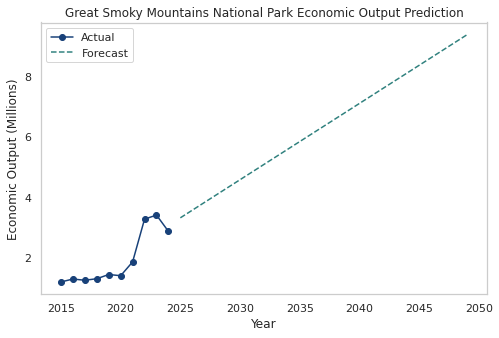

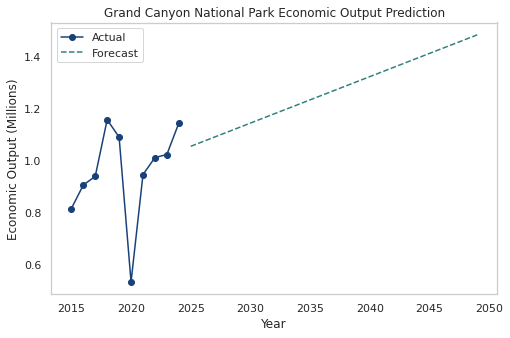

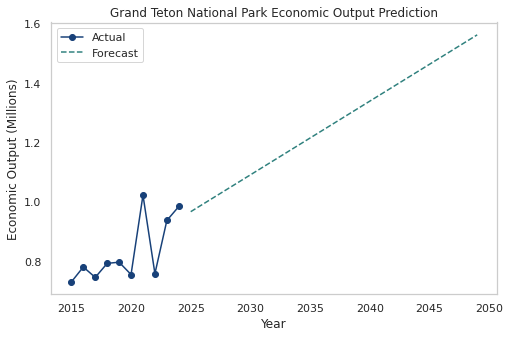

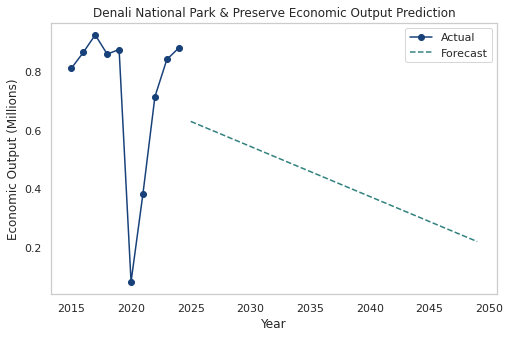

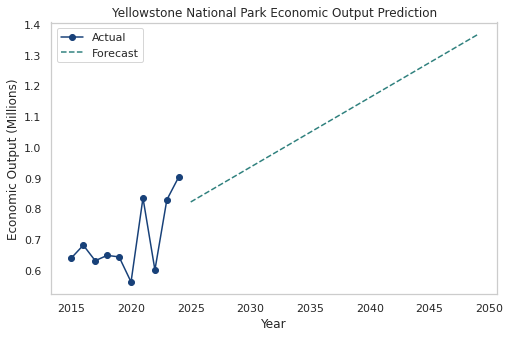

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DF_all["Economic Output"] = (
    DF_all["Economic Output"]
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

econ_yearly = (
    DF_all.groupby(["Park Name", "Year"])["Economic Output"]
    .sum()
    .reset_index()
)

top_econ = (
    econ_yearly.groupby("Park Name")["Economic Output"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

top5 = top_econ["Park Name"]

print(top_econ)

future_years = np.arange(
    econ_yearly["Year"].max() + 1,
    econ_yearly["Year"].max() + 26
)

for park in top5:
    park_data = econ_yearly[econ_yearly["Park Name"] == park]

    x = park_data["Year"]
    y = park_data["Economic Output"]

    m, b = np.polyfit(x, y, 1)

    future_pred = m * future_years + b

    plt.figure(figsize=(8,5))

    # actual
    plt.plot(x, y / 1_000_000, marker="o", label="Actual")

    # forecast
    plt.plot(future_years, future_pred / 1_000_000, linestyle="--", label="Forecast")

    plt.title(f"{park} Economic Output Prediction")
    plt.xlabel("Year")
    plt.ylabel("Economic Output (Millions)")
    plt.legend()
    plt.grid()

    plt.show()
